# Hierarchical Clustering and Cluster Evaluation


Let us consider presidential elections of years past and do some exploratory grouping of states based on the 2008,2012, and 2016 presidential elections results.  The data we have is from the [The American Presidency Project](https://www.presidency.ucsb.edu/statistics/elections) and split into two files:

  - `votes_by_state.csv` => has the raw number of ballots cast for each of the top presidential candidates from 2008-2012 by US State (and the District of Columbia)
  - `republican_percentage_by_state.csv` => has the percentage of votes that were for the Republican candidate for 2008, 2012, and 2016 by US State (and the District of Columbia)
  
Our job is to group together states using different hierarchical agglomerative methodologies and compare the results. We can imagine how finding states that tend to vote similarly to each other might be useful for election predictions, or for identifying swing states as part of a political campaign to invest in.

In [1]:
# Importing regular libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

# For our hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

# For our k-means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

## Using Different Proximity Functions

We will use the scientific python library, SciPy, which has [library for hierarchical clustering](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage) and for [plotting dendrograms](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html#scipy.cluster.hierarchy.dendrogram). 

We will use these libraries to plot the hierarchical clusters formed from the raw vote count (`votes_by_state.csv`) using three different proximity measures:
  - Ward
  - Min
  - Max
  

In [2]:
# Loading the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('votes_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])
states = s_states.to_list()

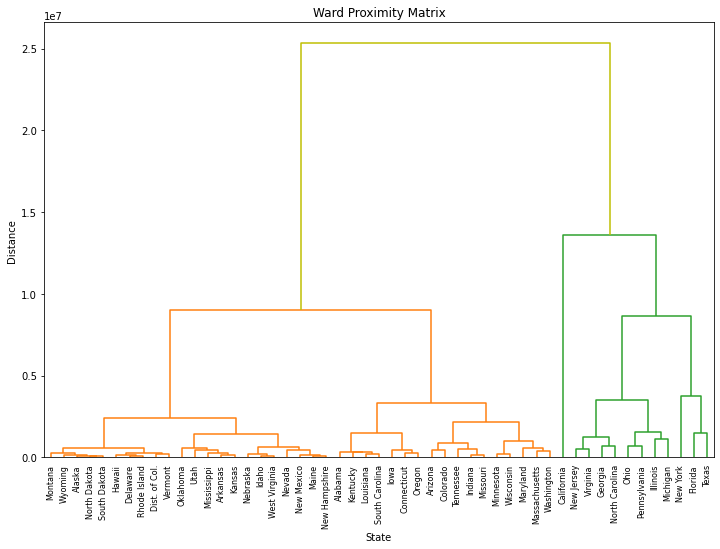

In [3]:
# Ploting the dendrogram for the Ward proximity measure
Z = linkage(df_X, 'ward')

fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Ward Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

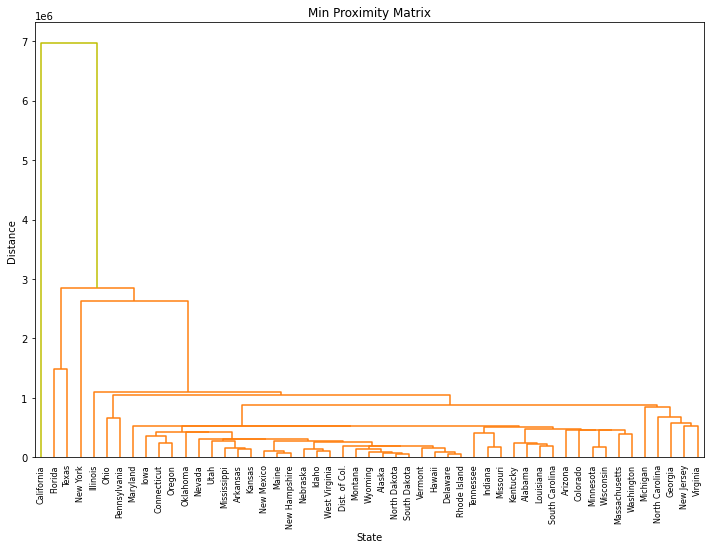

In [4]:
# Ploting the dendrogram for the min proximity measure
Z = linkage(df_X, 'single')
fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Min Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

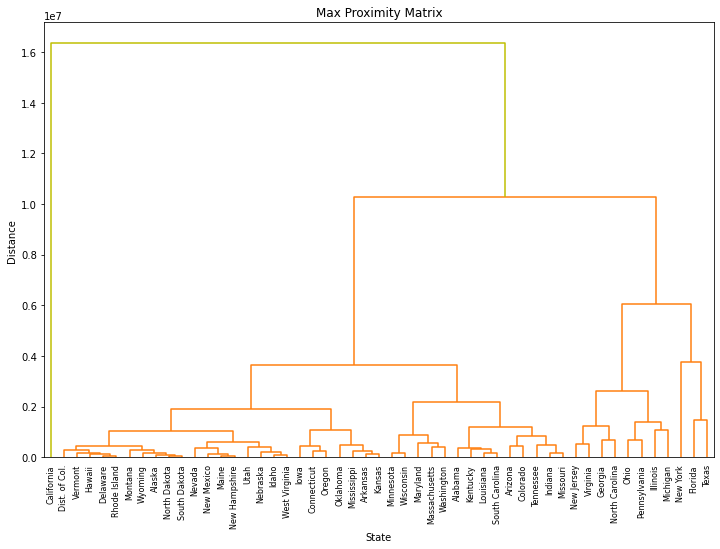

In [5]:
# Ploting the dendrogram for the max proximity measure
Z = linkage(df_X, 'complete')
fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Max Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

## Using Different Proximity Functions (part 2)

Looking at the graphs we might find it strange that New York is closer to Texas than it is to California in all of those graphs. We can also notice that Montana, Wyoming, and Alaska all tend to cluster together in all of these scenarios. 

At this point, it seems that the _population_ of that state seems to be more important than which party _won_ the state. We can engineer the data such that we reduce the dimensions down from 7 attributes, to 3 attributes, where each column is the _percentage_ of votes that were cast to the Republican candidate, and a 4th attribute indicating the range of percentages across the 3 elections. These changes are represented in the file `republican_percentage_by_state.csv`. 

We can Plot the hierarchical clusters formed from percentage of ballots cast by Republicans (`republican_percentage_by_state.csv`) using three different proximity measures:
  - Ward
  - Min
  - Max
  

In [6]:
# Loading the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('republican_percentage_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])

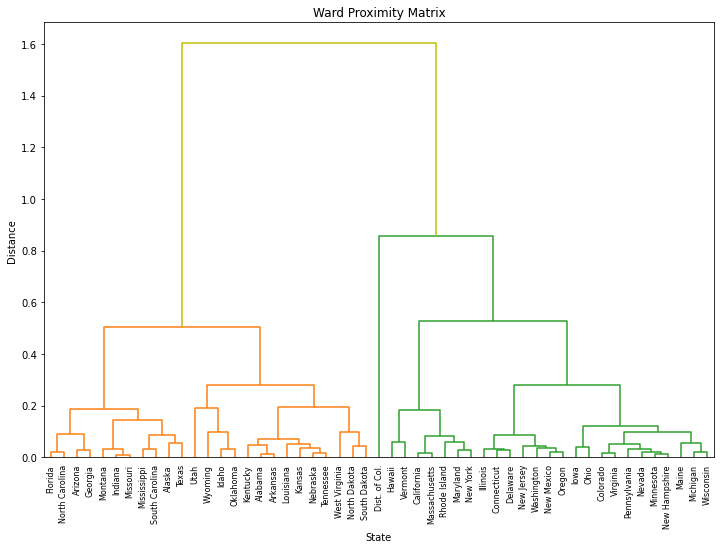

In [7]:
# Ploting the dendrogram for the Ward proximity measure
Z = linkage(df_X, 'ward')

fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Ward Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

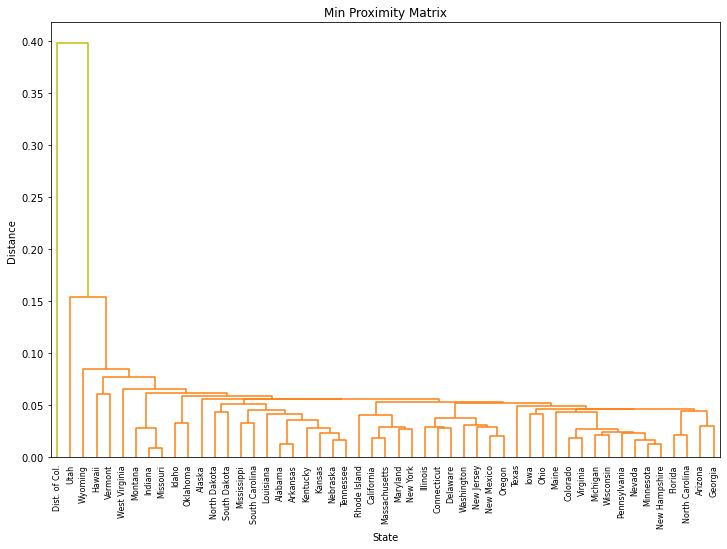

In [8]:
# Ploting the dendrogram for the min proximity measure
Z = linkage(df_X, 'single')
fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Min Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

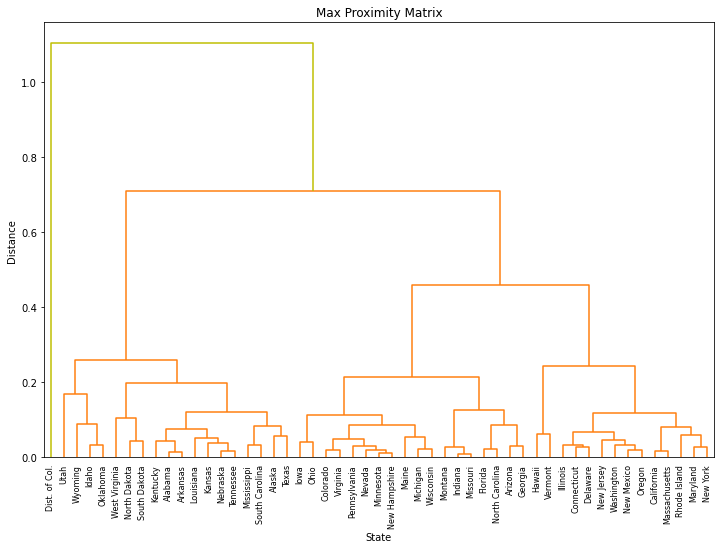

In [9]:
# Ploting the dendrogram for the max proximity measure
Z = linkage(df_X, 'complete')
fig = plt.subplots(1, figsize=(12, 8))
dn = dendrogram(Z, above_threshold_color='y', orientation='top', labels = states, leaf_font_size = 8)
plt.title('Max Proximity Matrix')
plt.xlabel('State')
plt.ylabel('Distance')
plt.show()

## Calculating the Cophenetic Correlation Coefficient (CPCC)

Using the data from part 2 (creating hierarchical clusters on the percentage of Republican votes), we will calculate the Cophenetic Correlation Coefficient for each of the three methods. We will use the scipy [cophenet function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.cophenet.html) with the output from  [pdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html) function as the `Y` parameter. 

In [10]:
Z = linkage(df_X, 'ward')
Y = pdist(df_X)
cpcc_ward = cophenet(Z, Y)

Z = linkage(df_X, 'single')
Y = pdist(df_X)
cpcc_min = cophenet(Z, Y)

Z = linkage(df_X, 'complete')
Y = pdist(df_X)
cpcc_max = cophenet(Z, Y)

In [11]:
# Showing the results
(cpcc_ward,cpcc_min,cpcc_max)

((0.5883071696030502,
  array([0.50568076, 0.50568076, 0.01296599, ..., 1.60317582, 0.28157632,
         1.60317582])),
 (0.695463585768092,
  array([0.05618547, 0.05593813, 0.01296599, ..., 0.06554072, 0.08481294,
         0.08481294])),
 (0.7406937703705782,
  array([0.12015468, 0.70887648, 0.01296599, ..., 0.70887648, 0.25852925,
         0.70887648])))

CPCC indicates how well a dendrogram preserves the pairwise distances between the original unmodeled data points. There was a 59% preservation when using the Ward proximity measure, 70% when using the min proximity measure, and 74% when using the max promitity measure. As the CPCC approaches 100%, it is indicative that the clustering is fit well. This means that the max promitity measure fits the data the best, followed by the min proximity measure, and the Ward promitity measure fits the clusters the worst. This shows that Euclidean distance is not always the best way to group things. 

## Finding new Clusters Based on K-Means

Lets us assume that we are asked approched by a political campaign to come up with 4 different strategies based on the clustering that you have done. Our hierarchical clustering didn't come up with a natural 4 clustersbut we canuse k-means to come up with the 4 clusters. We will use the following points to initialize your cluster centers based on the Ward proximity graph in your hierarchical clusters:

  - Montana
  - Arkansas
  - Massachusetts
  - Minnesota

We will pass `random_state = 23` into the [KMeans function](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

In [12]:
# Finding the centroids
centroids = df_X[(s_states == 'Montana') | (s_states == 'Arkansas') | (s_states == 'Massachusetts') | (s_states == 'Minnesota')]

In [13]:
# Showing the centroids
centroids

,2016,2012,2008,range
3,0.625343,0.621544,0.601717,0.023625
21,0.338355,0.382143,0.368029,0.043788
23,0.471869,0.460588,0.447706,0.024163
26,0.575769,0.570342,0.511694,0.064075


In [14]:
# Computing the k-means clusters and show the listing of the States in each cluster
kmeans = KMeans(n_clusters=len(centroids), random_state = 23, init=np.array(centroids), n_init = 1)
label = kmeans.fit_predict(df_X)
df_X['label'] = label
df_X = df_X.sort_values(by = 'label', ascending=True)

## Visualizing the Silhouette Coefficients for Each Cluster

Using the [Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html) implementation in sci-kit learn, we will calculate the silhouette coefficient for each of the States in our data frame using the clustering from the previous part, and create a bar graph. 
We will use the Silhouette Coefficient plot to identify clusters that have outliers. Then we will find the data points that are outliers. 

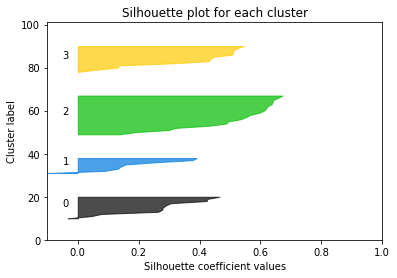

In [15]:
sample_silhouette_values = silhouette_samples(df_X.loc[:, df_X.columns != 'label'], df_X['label'])

fig, (ax1) = plt.subplots(1, 1)
ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(df_X) + (len(centroids) + 1) * 10])

y_lower = 10
for i in range(len(centroids)):
    ith_cluster_silhouette_values = sample_silhouette_values[df_X['label'] == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / len(centroids))
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10
    ax1.set_title('Silhouette plot for each cluster')
    ax1.set_xlabel('Silhouette coefficient values')
    ax1.set_ylabel('Cluster label')

plt.show()

In [16]:
#finding the outliers
outliers = []
for i in range(len(sample_silhouette_values)):
    if sample_silhouette_values[i] < 0:
        outliers.append(i)
s_states[outliers]

6     Connecticut
14        Indiana
Name: State, dtype: object